In [ ]:
!pip install bitsandbytes trl

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from copy import deepcopy
from numpy.linalg import matrix_rank
from peft import LoraConfig, get_peft_model,prepare_model_for_kbit_training, PeftConfig
from transformers import AutoModelForCausalLM,BitsAndBytesConfig

quantization된 layer는 weight가 동결되어 있고, LoRA adapter부분만 학습이 진행된다.

In [ ]:
#attention module에 있는 Linear layer
base_layer=nn.Linear(1024,1024,bias=False)
base_layer.weight.shape, base_layer.weight.numel()

(torch.Size([1024, 1024]), 1048576)

In [ ]:
torch.manual_seed(11)
r=8   #matrix의 rank를 8로 선택
layer_A=nn.Linear(base_layer.in_features,r,bias=False)
layer_B=nn.Linear(r,base_layer.out_features,bias=False)
layer_A,layer_B

(Linear(in_features=1024, out_features=8, bias=False),
 Linear(in_features=8, out_features=1024, bias=False))

In [ ]:
#각 layer는 8192개의 parameter만 갖고 있다.
layer_A.weight.numel(), layer_B.weight.numel()

(8192, 8192)

In [ ]:
#이를 곱하면 완전한 크기인 백만 개의 parameter matrix가 만들어진다.
composite=layer_B.weight @ layer_A.weight
composite.shape,composite.numel()

(torch.Size([1024, 1024]), 1048576)

In [ ]:
#rank확인
matrix_rank(composite.detach().numpy())

np.int64(8)

In [ ]:
#forward pass 과정
torch.manual_seed(19)
batch=torch.randn(1,1024)
batch @ (base_layer.weight.data + layer_B.weight @ layer_A.weight).T

tensor([[-0.3628, -0.3309, -1.1782,  ...,  0.6188,  0.0566,  0.4228]],
       grad_fn=<MmBackward0>)

In [ ]:
#더 효율적인 forward pass 과정
regular_output=batch @ base_layer.weight.data.T
additional_output=batch @ (layer_B.weight @ layer_A.weight).T
regular_output, additional_output

(tensor([[-0.3271, -0.3539, -0.7175,  ...,  0.9108, -0.1378, -0.0813]]),
 tensor([[-0.0357,  0.0230, -0.4607,  ..., -0.2920,  0.1944,  0.5041]],
        grad_fn=<MmBackward0>))

In [ ]:
#adapter의 forward pass 분할하기(LoRA부분)
out_A=(batch @ layer_A.weight.T)
additional_output=out_A @ layer_B.weight.T
additional_output

tensor([[-0.0357,  0.0230, -0.4607,  ..., -0.2920,  0.1944,  0.5041]],
       grad_fn=<MmBackward0>)

In [ ]:
#위 2코드를 종합하면 다음과 같다.
regular_output=base_layer(batch)
out_A=layer_A(batch)
additional_output=layer_B(out_A)
output=regular_output + additional_output
regular_output, additional_output, output

(tensor([[-0.3271, -0.3539, -0.7175,  ...,  0.9108, -0.1378, -0.0813]],
        grad_fn=<MmBackward0>),
 tensor([[-0.0357,  0.0230, -0.4607,  ..., -0.2920,  0.1944,  0.5041]],
        grad_fn=<MmBackward0>),
 tensor([[-0.3628, -0.3309, -1.1782,  ...,  0.6188,  0.0566,  0.4228]],
        grad_fn=<AddBackward0>))

In [ ]:
#LoRA의 scaling 인자
alpha=2*r
output=regular_output + (alpha/r)*additional_output
output

tensor([[-0.3985, -0.3079, -1.6388,  ...,  0.3267,  0.2510,  0.9268]],
       grad_fn=<AddBackward0>)

In [ ]:
#2장에서의 주요 코드(3장에서 사용예정)
supported=torch.cuda.is_bf16_supported(including_emulation=False)
compute_dtype=(torch.bfloat16 if supported else torch.float32)

nf4_config=BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=compute_dtype
)

model_q4=AutoModelForCausalLM.from_pretrained(
    "facebook/opt-350m",device_map="cuda:0",dtype=compute_dtype,
    quantization_config=nf4_config
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/644 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/663M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/662M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

In [ ]:
#훈련 가능한 parameter을 살펴보겠다.
def trainable_parms(model):
  parms=[(name,param.dtype) for name, param in model.named_parameters()
          if param.requires_grad]
  return parms
trainable_parms(model_q4.model)

[('decoder.embed_tokens.weight', torch.float32),
 ('decoder.embed_positions.weight', torch.float32),
 ('decoder.layers.0.self_attn.k_proj.bias', torch.float32),
 ('decoder.layers.0.self_attn.v_proj.bias', torch.float32),
 ('decoder.layers.0.self_attn.q_proj.bias', torch.float32),
 ('decoder.layers.0.self_attn.out_proj.bias', torch.float32),
 ('decoder.layers.0.self_attn_layer_norm.weight', torch.float32),
 ('decoder.layers.0.self_attn_layer_norm.bias', torch.float32),
 ('decoder.layers.0.fc1.bias', torch.float32),
 ('decoder.layers.0.fc2.bias', torch.float32),
 ('decoder.layers.0.final_layer_norm.weight', torch.float32),
 ('decoder.layers.0.final_layer_norm.bias', torch.float32),
 ('decoder.layers.1.self_attn.k_proj.bias', torch.float32),
 ('decoder.layers.1.self_attn.v_proj.bias', torch.float32),
 ('decoder.layers.1.self_attn.q_proj.bias', torch.float32),
 ('decoder.layers.1.self_attn.out_proj.bias', torch.float32),
 ('decoder.layers.1.self_attn_layer_norm.weight', torch.float32),
 ('

In [ ]:
#quantization된 model을 훈련을 위해 전처리해야 한다.
#model의 훈련 가능한 어떤 층도 더 이상 훈련되지 않도록 한다.
#quantization되지 않은 모든 16bits layer을 FP32로 변환

prepared_model=prepare_model_for_kbit_training(model_q4, use_gradient_checkpointing=True,
                                               gradient_checkpointing_kwargs={"use_reentrant":False})
prepared_model

OPTForCausalLM(
  (model): OPTModel(
    (decoder): OPTDecoder(
      (embed_tokens): Embedding(50272, 512, padding_idx=1)
      (embed_positions): OPTLearnedPositionalEmbedding(2050, 1024)
      (project_out): Linear4bit(in_features=1024, out_features=512, bias=False)
      (project_in): Linear4bit(in_features=512, out_features=1024, bias=False)
      (layers): ModuleList(
        (0-23): 24 x OPTDecoderLayer(
          (self_attn): OPTAttention(
            (k_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
          )
          (activation_fn): ReLU()
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (fc1): Linear4bit(in_features=1024, out_features=4096, bias=True)
          (

In [ ]:
#훈련 가능한 parameter는?
trainable_parms(prepared_model)

[]

In [ ]:
#FP32 타입의 parameter를 가진 layer의 이름은?
def parms_of_dtype(model, dtype=torch.float32):
  parms=[name for name, param in model.named_parameters()
                  if param.dtype==dtype]
  return parms
parms_of_dtype(prepared_model)


['model.decoder.embed_tokens.weight',
 'model.decoder.embed_positions.weight',
 'model.decoder.layers.0.self_attn.k_proj.bias',
 'model.decoder.layers.0.self_attn.v_proj.bias',
 'model.decoder.layers.0.self_attn.q_proj.bias',
 'model.decoder.layers.0.self_attn.out_proj.bias',
 'model.decoder.layers.0.self_attn_layer_norm.weight',
 'model.decoder.layers.0.self_attn_layer_norm.bias',
 'model.decoder.layers.0.fc1.bias',
 'model.decoder.layers.0.fc2.bias',
 'model.decoder.layers.0.final_layer_norm.weight',
 'model.decoder.layers.0.final_layer_norm.bias',
 'model.decoder.layers.1.self_attn.k_proj.bias',
 'model.decoder.layers.1.self_attn.v_proj.bias',
 'model.decoder.layers.1.self_attn.q_proj.bias',
 'model.decoder.layers.1.self_attn.out_proj.bias',
 'model.decoder.layers.1.self_attn_layer_norm.weight',
 'model.decoder.layers.1.self_attn_layer_norm.bias',
 'model.decoder.layers.1.fc1.bias',
 'model.decoder.layers.1.fc2.bias',
 'model.decoder.layers.1.final_layer_norm.weight',
 'model.decode

In [ ]:
prepared_model.get_memory_footprint()/1e6

264.15104

#PEFT(Parameter Efficient Fine Tuning)

In [ ]:
#quantization된 model에 적용할 설정 생성
lora_config=LoraConfig()
lora_config

LoraConfig(task_type=None, peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.19.1', base_model_name_or_path=None, revision=None, inference_mode=False, r=8, target_modules=None, exclude_modules=None, lora_alpha=8, lora_dropout=0.0, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None, use_bdlora=None, arrow_config=None, ensure_weight_tying=False)

In [ ]:
config=LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

In [ ]:
#사용하려는 model구조가 PEFT package에서 지원하는지 확인
from peft.utils.constants import TRANSFORMERS_MODELS_TO_LORA_TARGET_MODULES_MAPPING

print(TRANSFORMERS_MODELS_TO_LORA_TARGET_MODULES_MAPPING.keys())
print("\n\n\n")
#혹은
print(TRANSFORMERS_MODELS_TO_LORA_TARGET_MODULES_MAPPING['phi'])

dict_keys(['t5', 'mt5', 'bart', 'gpt2', 'bloom', 'blip-2', 'opt', 'gptj', 'gpt_neox', 'gpt_neo', 'bert', 'roberta', 'xlm-roberta', 'electra', 'deberta-v2', 'deberta', 'layoutlm', 'llama', 'llama4', 'chatglm', 'gpt_bigcode', 'mpt', 'RefinedWebModel', 'RefinedWeb', 'falcon', 'btlm', 'codegen', 'mistral', 'mixtral', 'stablelm', 'phi', 'gemma', 'gemma2', 'gemma3_text', 'gemma4', 'qwen2', 'qwen3', 'rwkv', 'rwkv7'])




['q_proj', 'v_proj', 'fc1', 'fc2']


In [ ]:
TRANSFORMERS_MODELS_TO_LORA_TARGET_MODULES_MAPPING['opt']

['q_proj', 'v_proj']

In [ ]:
#q_proj와 v_proj에만 adapter를 추가해보겠다(위에서 보듯 opt모델의 이러한 설정은 사전에 되어있다.).
peft_model=get_peft_model(prepared_model,config,adapter_name="default")
peft_model

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): OPTForCausalLM(
      (model): OPTModel(
        (decoder): OPTDecoder(
          (embed_tokens): Embedding(50272, 512, padding_idx=1)
          (embed_positions): OPTLearnedPositionalEmbedding(2050, 1024)
          (project_out): Linear4bit(in_features=1024, out_features=512, bias=False)
          (project_in): Linear4bit(in_features=512, out_features=1024, bias=False)
          (layers): ModuleList(
            (0-23): 24 x OPTDecoderLayer(
              (self_attn): OPTAttention(
                (k_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
                (v_proj): lora.Linear4bit(
                  (base_layer): Linear4bit(in_features=1024, out_features=1024, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.05, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=1024, out_fea

In [ ]:
#수정된 q_proj layer을 자세히 살펴보겠다.
lin=(peft_model.base_model.model.model.decoder.layers[0].self_attn.q_proj)
lin

lora.Linear4bit(
  (base_layer): Linear4bit(in_features=1024, out_features=1024, bias=True)
  (lora_dropout): ModuleDict(
    (default): Dropout(p=0.05, inplace=False)
  )
  (lora_A): ModuleDict(
    (default): Linear(in_features=1024, out_features=8, bias=False)
  )
  (lora_B): ModuleDict(
    (default): Linear(in_features=8, out_features=1024, bias=False)
  )
  (lora_embedding_A): ParameterDict()
  (lora_embedding_B): ParameterDict()
  (lora_magnitude_vector): ModuleDict()
)

In [ ]:
#이 모델이 갖는 훈련 가능한 parameter 개수와 전체 parameter에 관한 비율
peft_model.print_trainable_parameters()

trainable params: 786,432 || all params: 331,982,848 || trainable%: 0.2369


In [ ]:
#훈련 가능한 parameter 모두 추가된 adapter에 있다.
trainable_parms(peft_model.base_model.model)

[('model.decoder.layers.0.self_attn.v_proj.lora_A.default.weight',
  torch.float32),
 ('model.decoder.layers.0.self_attn.v_proj.lora_B.default.weight',
  torch.float32),
 ('model.decoder.layers.0.self_attn.q_proj.lora_A.default.weight',
  torch.float32),
 ('model.decoder.layers.0.self_attn.q_proj.lora_B.default.weight',
  torch.float32),
 ('model.decoder.layers.1.self_attn.v_proj.lora_A.default.weight',
  torch.float32),
 ('model.decoder.layers.1.self_attn.v_proj.lora_B.default.weight',
  torch.float32),
 ('model.decoder.layers.1.self_attn.q_proj.lora_A.default.weight',
  torch.float32),
 ('model.decoder.layers.1.self_attn.q_proj.lora_B.default.weight',
  torch.float32),
 ('model.decoder.layers.2.self_attn.v_proj.lora_A.default.weight',
  torch.float32),
 ('model.decoder.layers.2.self_attn.v_proj.lora_B.default.weight',
  torch.float32),
 ('model.decoder.layers.2.self_attn.q_proj.lora_A.default.weight',
  torch.float32),
 ('model.decoder.layers.2.self_attn.q_proj.lora_B.default.weight'

In [ ]:
config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    modules_to_save=["layer_norm"]  #훈련 가능한 layer list를 지정
)
peft_model=get_peft_model(prepared_model,config)
peft_model.print_trainable_parameters()

trainable params: 884,736 || all params: 332,081,152 || trainable%: 0.2664


/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [ ]:
#embedding layer도 훈련 가능한 layer list에 추가하자.
#새로운 token을 위해 embedding layer을 fine-tuning해야 한다.

config=LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    modules_to_save=["layer_norm","embed_tokens"]
)

In [ ]:
peft_model=get_peft_model(prepared_model,config)
peft_model.print_trainable_parameters()

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:1348: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


trainable params: 26,624,000 || all params: 357,820,416 || trainable%: 7.4406


In [ ]:
#새로운 token을 위해 embedding layer을 fine-tuning해야 한다.
#다른 방법으로는 adapter를 embedding layer에 추가한다.
config=LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["embed_tokens","q_proj","v_proj"]
)

다음 코드가 없을 시

!pip install torchao==0.16.0

-----------------------------


peft_model=get_peft_model(prepared_model,config)
peft_model.print_trainable_parameters()

위 코드에서 다음과 같은 오류가 발생한다.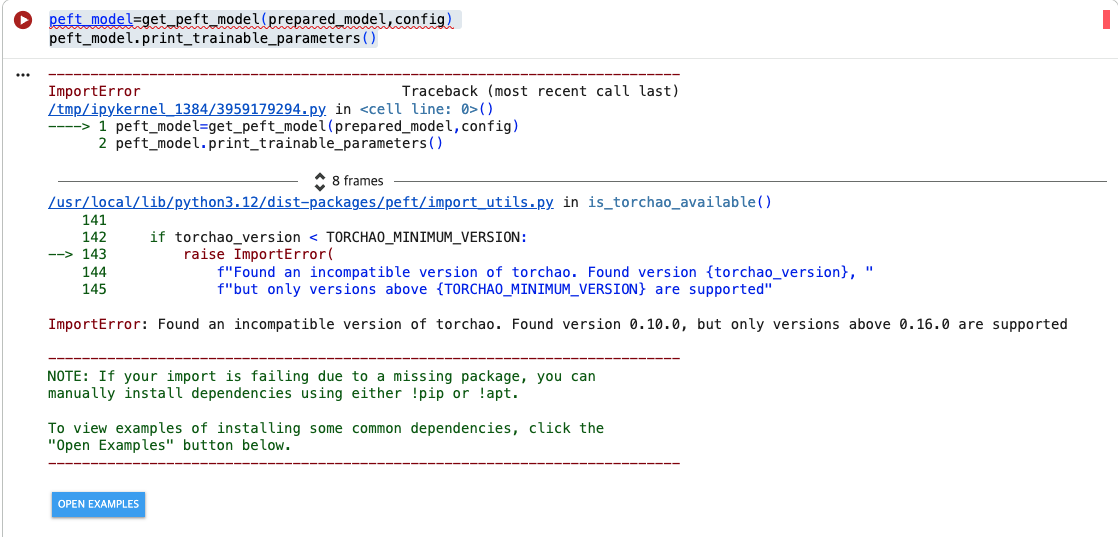


In [ ]:
#torchao 버전 업
!pip install torchao==0.16.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 30.7 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [ ]:
# `get_peft_model()` 함수는 입력된 모델을 수정하므로 다른 설정 객체로 반복해서 호출하면 설정이 꼬이게 됩니다.
# 일반적인 워크플로에서는 설정을 한 번만 로드하므로 이런 코드가 필요하지 않습니다.
_ = peft_model.unload()

In [ ]:
peft_model=get_peft_model(prepared_model,config)
peft_model.print_trainable_parameters()

trainable params: 1,192,704 || all params: 358,128,384 || trainable%: 0.3330


In [ ]:
#수정된 embedding layer 확인
#이 설정에서는 입력 embedding만 수정된다.
lin=peft_model.base_model.model.model.decoder.embed_tokens
lin

lora.Embedding(
  (base_layer): Embedding(50272, 512, padding_idx=1)
  (lora_dropout): ModuleDict(
    (default): Dropout(p=0.05, inplace=False)
  )
  (lora_A): ModuleDict()
  (lora_B): ModuleDict()
  (lora_embedding_A): ParameterDict(  (default): Parameter containing: [torch.cuda.FloatTensor of size 8x50272 (cuda:0)])
  (lora_embedding_B): ParameterDict(  (default): Parameter containing: [torch.cuda.FloatTensor of size 512x8 (cuda:0)])
  (lora_magnitude_vector): ModuleDict()
)

In [ ]:
#adapter관리
peft_model.load_adapter("dvgodoy/opt-350m-lora-yoda",adapter_name="yoda")
lora_A=(peft_model.base_model.model.model.decoder.layers[0].self_attn.q_proj.lora_A)
lora_A


adapter_config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/3.16M [00:00<?, ?B/s]

ModuleDict(
  (default): Linear(in_features=1024, out_features=8, bias=False)
  (yoda): Linear(in_features=1024, out_features=8, bias=False)
)

In [ ]:
#위 출력 결과에서 보듯 q_proj layer에 두 개의 adapter가 있다.
#여기에 또 다른 adapter를 추가해보겠다.
peft_model.add_adapter(adapter_name="third",peft_config=config)
lora_A

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:1348: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


ModuleDict(
  (default): Linear(in_features=1024, out_features=8, bias=False)
  (yoda): Linear(in_features=1024, out_features=8, bias=False)
  (third): Linear(in_features=1024, out_features=8, bias=False)
)

In [ ]:
#이중 adapter하나를 삭제해보겠다.
peft_model.delete_adapter(adapter_name="third")
lora_A

ModuleDict(
  (default): Linear(in_features=1024, out_features=8, bias=False)
  (yoda): Linear(in_features=1024, out_features=8, bias=False)
)

In [ ]:
#model에 남아있는 adapter살펴보기
peft_model.peft_config.keys()

dict_keys(['default', 'yoda'])

In [ ]:
#활성화된 adapter보기
peft_model.active_adapter

'default'

In [ ]:
#다른 adapter사용하기
peft_model.set_adapter("yoda")
peft_model.active_adapter

'yoda'

    #일시적으로 adapter비활성화 혹은 base model자체 호출
    with peft_model.disable_adapter():    #context 관리자
      original_outputs=peft_model(inputs)

    original_outputs=peft_model.base_model(inputs)    #base model 호출

In [ ]:
#adapter의 weight를 base model layer에 합침
peft_model.merge_adapter(adapter_names=["yoda"])
lora_A

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:629: UserWarning: Model with `tie_word_embeddings=True` and the tied_target_modules=['model.decoder.embed_tokens', 'model.decoder.embed_tokens'] are part of the adapter. This can lead to complications. You can opt to merge the adapter after cloning the weights (to untie the embeddings). You can untie the embeddings by loading the model with `tie_word_embeddings=False`. For example:
```python
from transformers import AutoModelForCausalLM

# Load original tied model
model = AutoModelForCausalLM.from_pretrained("google/gemma-2-2b-it", tie_word_embeddings=False)

# Set the randomly initialized lm_head to the previously tied embeddings
model.lm_head.weight.data = model.model.embed_tokens.weight.data.clone()

# Save the untied model
untied_model_dir = "dir/for/untied/model"
model.save_pretrained(untied_model_dir)
model.config.save_pretrained(untied_model_dir)

# Now use the original model but in untied format
model = AutoMod

ModuleDict(
  (default): Linear(in_features=1024, out_features=8, bias=False)
  (yoda): Linear(in_features=1024, out_features=8, bias=False)
)

In [ ]:
#adapter를 다 사용했고 모두 삭제
peft_model.unload()
peft_model.base_model.model.model.decoder.layers[0].self_attn

OPTAttention(
  (k_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
  (v_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
  (q_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
  (out_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
)